# Frustration Modeling and Dataset Finetuning
In this notebook, we process the Coveo clickstream dataset (`release_10_23_2020.csv`), clean the data, generate session-level heuristics based on frustration rules, and build a machine learning classification model to predict frustration.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load a subset of the dataset to save memory (e.g., first 100,000 rows)
# Adjust nrows as needed for testing
df = pd.read_csv('release_10_23_2020.csv', nrows=100000)
print(f"Loaded dataset with shape: {df.shape}")
df.head()


Loaded dataset with shape: (100000, 6)


,session_id_hash,event_type,product_action,product_skus_hash,server_timestamp_epoch_ms,hashed_url
0,00000005c19449b57d8d05dfc8b5474be0654032,pageview,NaN,NaN,1544469996111,da99729886aff70a02733b6cd69ee7df35622d9302347e...
1,00006a0ada94a5186163a25e9ed9c94481c820d9,pageview,NaN,NaN,1545737959865,e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9abf...
2,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908835402,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...
3,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908847263,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...
4,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,detail,90add4dd072e160034e98ddea257e0b59441eae00d8955...,1544909035879,8fa1ecf31ececb27ebe9c529966f3d1f907542fe138d5d...


In [2]:
# Clean data
# Remove unnecessary columns and drop duplicates
columns_to_keep = ['session_id_hash', 'event_type', 'product_action', 'server_timestamp_epoch_ms', 'hashed_url']
df = df[columns_to_keep]

# Drop rows with missing session_id_hash
df = df.dropna(subset=['session_id_hash'])

# Drop duplicates
initial_len = len(df)
df = df.drop_duplicates()
print(f"Dropped {initial_len - len(df)} duplicate rows. New shape: {df.shape}")

# Sort by session and timestamp
df = df.sort_values(['session_id_hash', 'server_timestamp_epoch_ms'])


Dropped 503 duplicate rows. New shape: (99497, 5)


In [3]:
# Feature Engineering at Session Level
# We want to extract features per session to determine if the user might be frustrated

def calculate_session_features(session_data):
    # Sort just in case
    session_data = session_data.sort_values('server_timestamp_epoch_ms')
    
    total_events = len(session_data)
    
    if total_events > 1:
        duration_ms = session_data['server_timestamp_epoch_ms'].iloc[-1] - session_data['server_timestamp_epoch_ms'].iloc[0]
    else:
        duration_ms = 0
    
    duration_sec = duration_ms / 1000.0
    
    # Event rate (events per second)
    event_rate = total_events / duration_sec if duration_sec > 0 else 0
    
    # Backtracking (revisiting the same URL)
    urls = session_data['hashed_url'].tolist()
    backtracks = 0
    seen_urls = set()
    for u in urls:
        if u in seen_urls:
            backtracks += 1
        else:
            seen_urls.add(u)
            
    # Rage clicks equivalent: more than 4 events in < 5 seconds
    rapid_bursts = 0
    timestamps = session_data['server_timestamp_epoch_ms'].tolist()
    for i in range(len(timestamps) - 4):
        if timestamps[i+4] - timestamps[i] < 5000:
            rapid_bursts += 1
            
    # Did they purchase?
    has_purchase = 1 if 'purchase' in session_data['product_action'].values else 0
            
    return pd.Series({
        'total_events': total_events,
        'duration_sec': duration_sec,
        'event_rate': event_rate,
        'backtracks': backtracks,
        'rapid_bursts': rapid_bursts,
        'has_purchase': has_purchase
    })

session_groups = df.groupby('session_id_hash')
sessions_df = session_groups.apply(calculate_session_features).reset_index()
print(f"Created features for {len(sessions_df)} sessions.")
sessions_df.head()


Created features for 7715 sessions.


,session_id_hash,total_events,duration_sec,event_rate,backtracks,rapid_bursts,has_purchase
0,00000005c19449b57d8d05dfc8b5474be0654032,1.0,0.000,0.000000,0.0,0.0,0.0
1,00006a0ada94a5186163a25e9ed9c94481c820d9,1.0,0.000,0.000000,0.0,0.0,0.0
2,00007d15aeb741b3cdd873cb3933351d699cc320,7.0,499.332,0.014019,1.0,0.0,0.0
3,0000c49d1359c87f112285d63a9fc0d4c50f73b4,3.0,253.383,0.011840,1.0,0.0,0.0
4,0001135282dbaf0e734345212ea6f8da9f5b66ed,1.0,0.000,0.000000,0.0,0.0,0.0


In [4]:
# Heuristic Labeling for Frustration
# We map our demo app rules to clickstream features:
# - Rage Clicks -> rapid_bursts > 0
# - Backtracking -> backtracks >= 3
# - Repeated failures -> high event count, no purchase

def label_frustration(row):
    # Rule 1: Rage clicking behavior
    if row['rapid_bursts'] >= 1:
        return 1
    # Rule 2: Excessive backtracking (ping-ponging)
    if row['backtracks'] >= 3:
        return 1
    # Rule 3: Wandering / Search struggle (many events, no success)
    if row['total_events'] >= 15 and row['has_purchase'] == 0:
        return 1
        
    return 0

sessions_df['is_frustrated'] = sessions_df.apply(label_frustration, axis=1)

print("Frustration Label Distribution:")
print(sessions_df['is_frustrated'].value_counts(normalize=True))


Frustration Label Distribution:
is_frustrated
0    0.709008
1    0.290992
Name: proportion, dtype: float64


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1086
           1       1.00      1.00      1.00       457

    accuracy                           1.00      1543
   macro avg       1.00      1.00      1.00      1543
weighted avg       1.00      1.00      1.00      1543

Confusion Matrix:


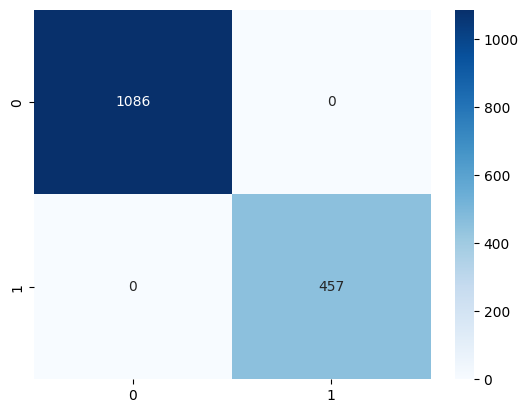

Feature Importances:
        feature  importance
3    backtracks    0.537009
0  total_events    0.319429
1  duration_sec    0.107597
2    event_rate    0.034868
4  rapid_bursts    0.001097


In [5]:
# Model Training
# We train a RandomForest model to predict the heuristic label.

features = ['total_events', 'duration_sec', 'event_rate', 'backtracks', 'rapid_bursts']
X = sessions_df[features]
y = sessions_df['is_frustrated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

# Feature Importance
importance = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
importance = importance.sort_values('importance', ascending=False)
print("Feature Importances:")
print(importance)
